In [1]:
# ETS Models
# Error/Residual, Trend and Seasonality

In [5]:
import numpy as np
import pandas as pd
%matplotlib inline

In [6]:
pwd

'/Users/sylvia/Desktop/Anomaly_Detection/Experiments'

In [7]:
df = pd.read_csv('/Users/sylvia/Desktop/Anomaly_Detection/Experiments/Data/real_15.csv', index_col = 'timestamp')

In [8]:
df.head()

,value,is_anomaly
timestamp,,
1,7350,0
2,6442,0
3,6057,0
4,7012,0
5,8847,0


In [9]:
len(df)

1439

In [10]:
df = df.dropna()

In [11]:
len(df) # There is no missing data

1439

In [12]:
# Plotting raw data

[Text(0, 0.5, 'traffic - yahoo properties'), Text(0.5, 0, 'hourly data')]

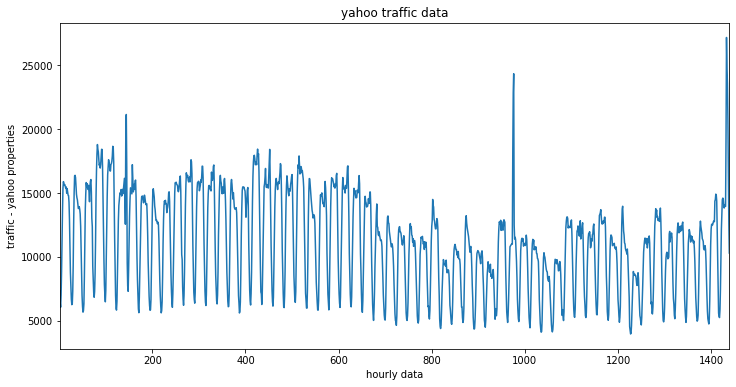

In [13]:
ax = df['value'].plot(figsize = (12,6), title = 'yahoo traffic data');
xlabel = 'hourly data'
ylabel = 'traffic - yahoo properties'
ax.set(xlabel = xlabel, ylabel = ylabel)

In [14]:
df.index

Int64Index([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
            ...
            1430, 1431, 1432, 1433, 1434, 1435, 1436, 1437, 1438, 1439],
           dtype='int64', name='timestamp', length=1439)

In [15]:
df.index = pd.to_datetime(df.index, unit = 'h')

In [94]:
df.head(30)

,value,is_anomaly
timestamp,,
1970-01-01 01:00:00,7350,0
1970-01-01 02:00:00,6442,0
1970-01-01 03:00:00,6057,0
1970-01-01 04:00:00,7012,0
1970-01-01 05:00:00,8847,0
1970-01-01 06:00:00,11371,0
1970-01-01 07:00:00,13525,0
1970-01-01 08:00:00,15386,0
1970-01-01 09:00:00,15896,0


[Text(0, 0.5, 'traffic - yahoo properties'), Text(0.5, 0, 'hourly data')]

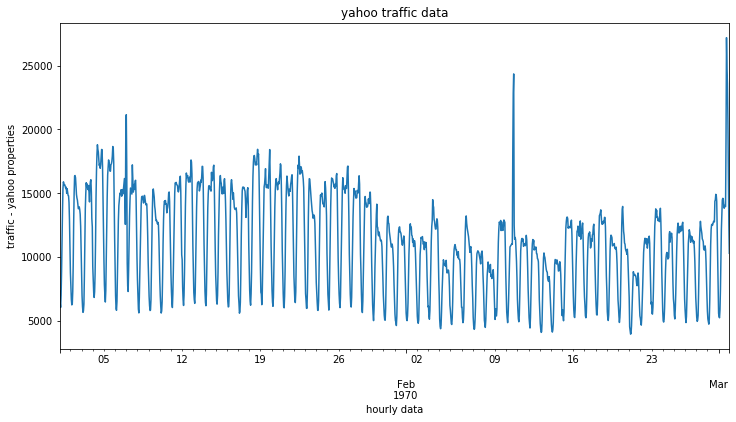

In [16]:
ax = df['value'].plot(figsize = (12,6), title = 'yahoo traffic data');
xlabel = 'hourly data'
ylabel = 'traffic - yahoo properties'
ax.set(xlabel = xlabel, ylabel = ylabel)

In [83]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [84]:
result = seasonal_decompose(df['value'], model = 'multiplicative')

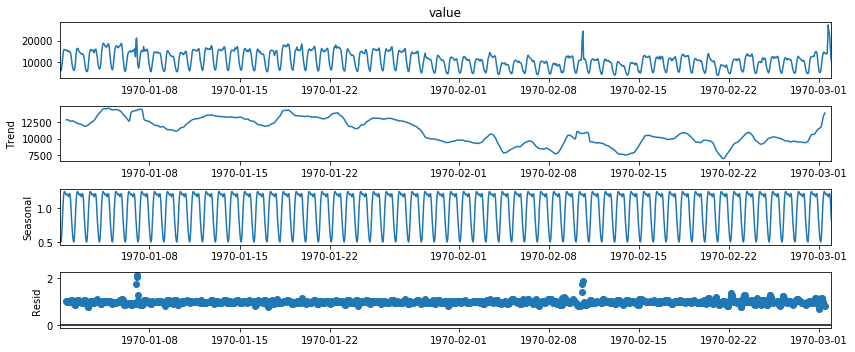

In [93]:
# To understand general behaviour of time series
from pylab import rcParams
rcParams['figure.figsize'] = 12,5

result.plot();
# Residual not explained by trend or seasonality - also it seems data is cleaner in beginning,
# more noise at end

In [92]:
result.trend.head(20)

timestamp
1970-01-01 01:00:00             NaN
1970-01-01 02:00:00             NaN
1970-01-01 03:00:00             NaN
1970-01-01 04:00:00             NaN
1970-01-01 05:00:00             NaN
1970-01-01 06:00:00             NaN
1970-01-01 07:00:00             NaN
1970-01-01 08:00:00             NaN
1970-01-01 09:00:00             NaN
1970-01-01 10:00:00             NaN
1970-01-01 11:00:00             NaN
1970-01-01 12:00:00             NaN
1970-01-01 13:00:00    12814.541667
1970-01-01 14:00:00    12829.125000
1970-01-01 15:00:00    12838.250000
1970-01-01 16:00:00    12827.750000
1970-01-01 17:00:00    12780.437500
1970-01-01 18:00:00    12705.395833
1970-01-01 19:00:00    12645.125000
1970-01-01 20:00:00    12619.312500
Name: trend, dtype: float64

In [89]:
result.seasonal.head(10)

timestamp
1970-01-01 01:00:00    0.586684
1970-01-01 02:00:00    0.520988
1970-01-01 03:00:00    0.500397
1970-01-01 04:00:00    0.550689
1970-01-01 05:00:00    0.684315
1970-01-01 06:00:00    0.873010
1970-01-01 07:00:00    1.052080
1970-01-01 08:00:00    1.173288
1970-01-01 09:00:00    1.235889
1970-01-01 10:00:00    1.241934
Name: seasonal, dtype: float64

In [91]:
result.resid.head(20)

timestamp
1970-01-01 01:00:00         NaN
1970-01-01 02:00:00         NaN
1970-01-01 03:00:00         NaN
1970-01-01 04:00:00         NaN
1970-01-01 05:00:00         NaN
1970-01-01 06:00:00         NaN
1970-01-01 07:00:00         NaN
1970-01-01 08:00:00         NaN
1970-01-01 09:00:00         NaN
1970-01-01 10:00:00         NaN
1970-01-01 11:00:00         NaN
1970-01-01 12:00:00         NaN
1970-01-01 13:00:00    1.016126
1970-01-01 14:00:00    0.997871
1970-01-01 15:00:00    1.000639
1970-01-01 16:00:00    0.981648
1970-01-01 17:00:00    1.030908
1970-01-01 18:00:00    1.007285
1970-01-01 19:00:00    0.969547
1970-01-01 20:00:00    0.972742
Name: resid, dtype: float64

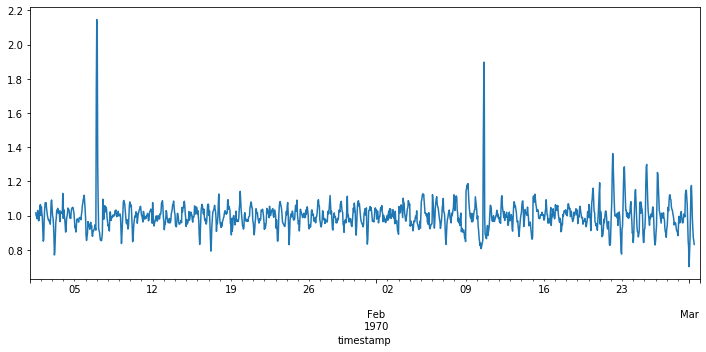

In [96]:
result.resid.plot(figsize = (12,5));

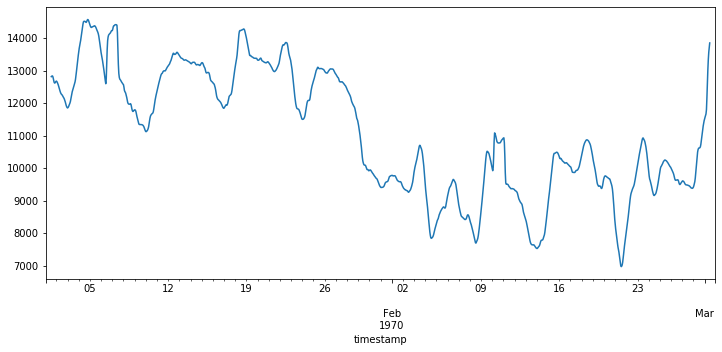

In [97]:
result.trend.plot(figsize = (12,5));

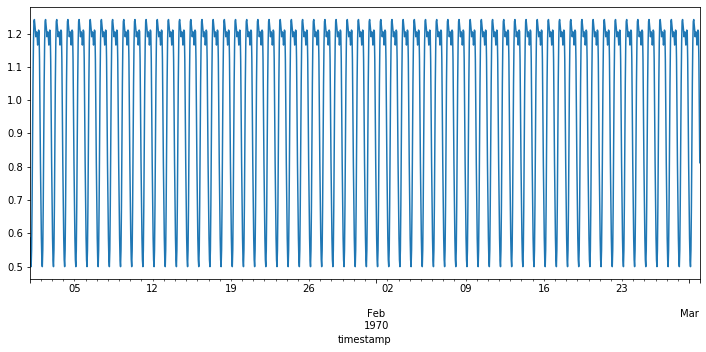

In [98]:
result.seasonal.plot(figsize = (12,5));